# Notebook Overview

This notebook is a results-comparison workspace.

- Goal: place PPO and Rainbow DQN metrics side by side
- Expected inputs: text files or saved metrics exported by the training/evaluation scripts
- Recommended use: verify that file paths point to the intended experiments before rerunning cells


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [2]:
ppo_files = [os.path.join('.\\comparison',file) for file in os.listdir('.\\comparison') if 'PPO' in file]
dqn_files = [os.path.join('.\\comparison',file) for file in os.listdir('.\\comparison') if 'DQN' in file]

In [3]:
print(ppo_files[3])
with open(ppo_files[3], 'r') as f:
    lines = f.readlines()

float_values = []
for line in lines:
    match = re.search(r'tensor\((-?\d+\.\d+)\)', line)
    if match:
        float_values.append(float(match.group(1)))

print(float_values)

.\comparison\PPO_delay_data.txt
[]


.\comparison\PPO_delay_data.txt
.\comparison\RDQN_delay_data.txt


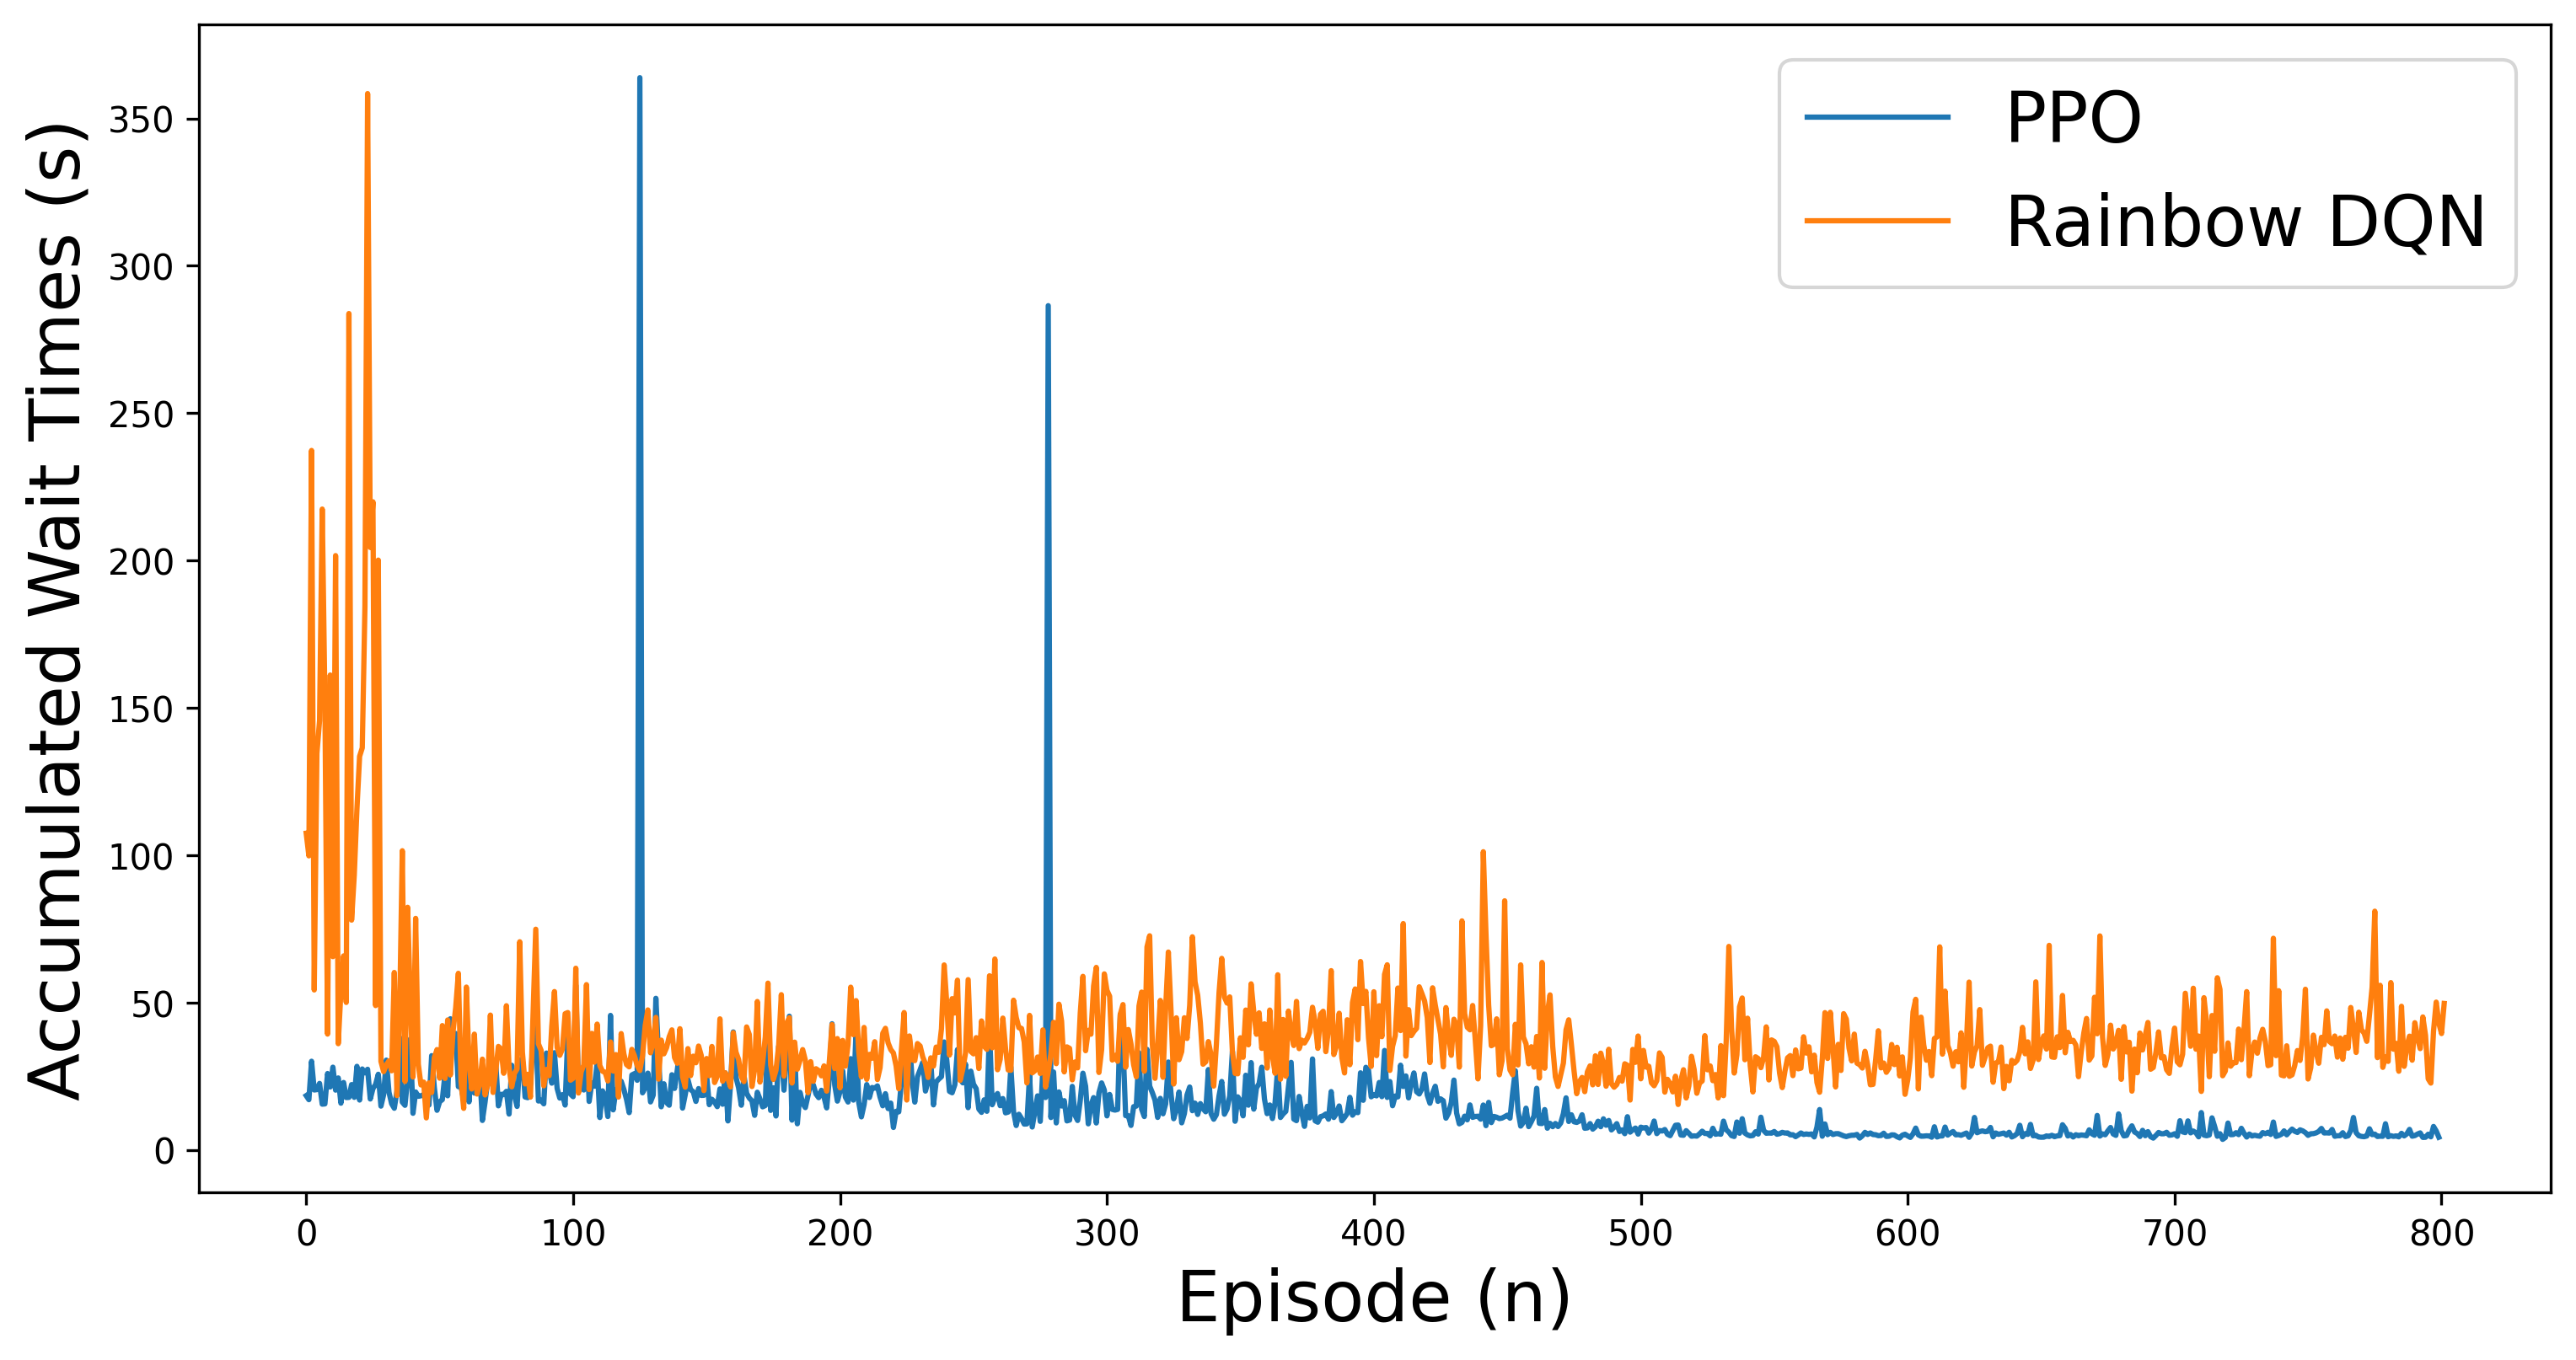

In [13]:
print(ppo_files[3])
delay_ppo = np.loadtxt(ppo_files[3])

print(dqn_files[0])
delay_dqn = np.loadtxt(dqn_files[0])

plt.figure(figsize=(12,6), dpi = 300)
plt.plot(delay_ppo, label='PPO')
plt.plot(delay_dqn, label='Rainbow DQN')
plt.ylabel('Accumulated Wait Times (s)', fontsize=20)
plt.xlabel('Episode (n)', fontsize=20)
plt.legend(fontsize=20)
plt.savefig('./comparison_delays.png', bbox_inches='tight', pad_inches=0.25)
plt.show()

.\comparison\PPO_queue_data.txt
.\comparison\RDQN_queue_data.txt


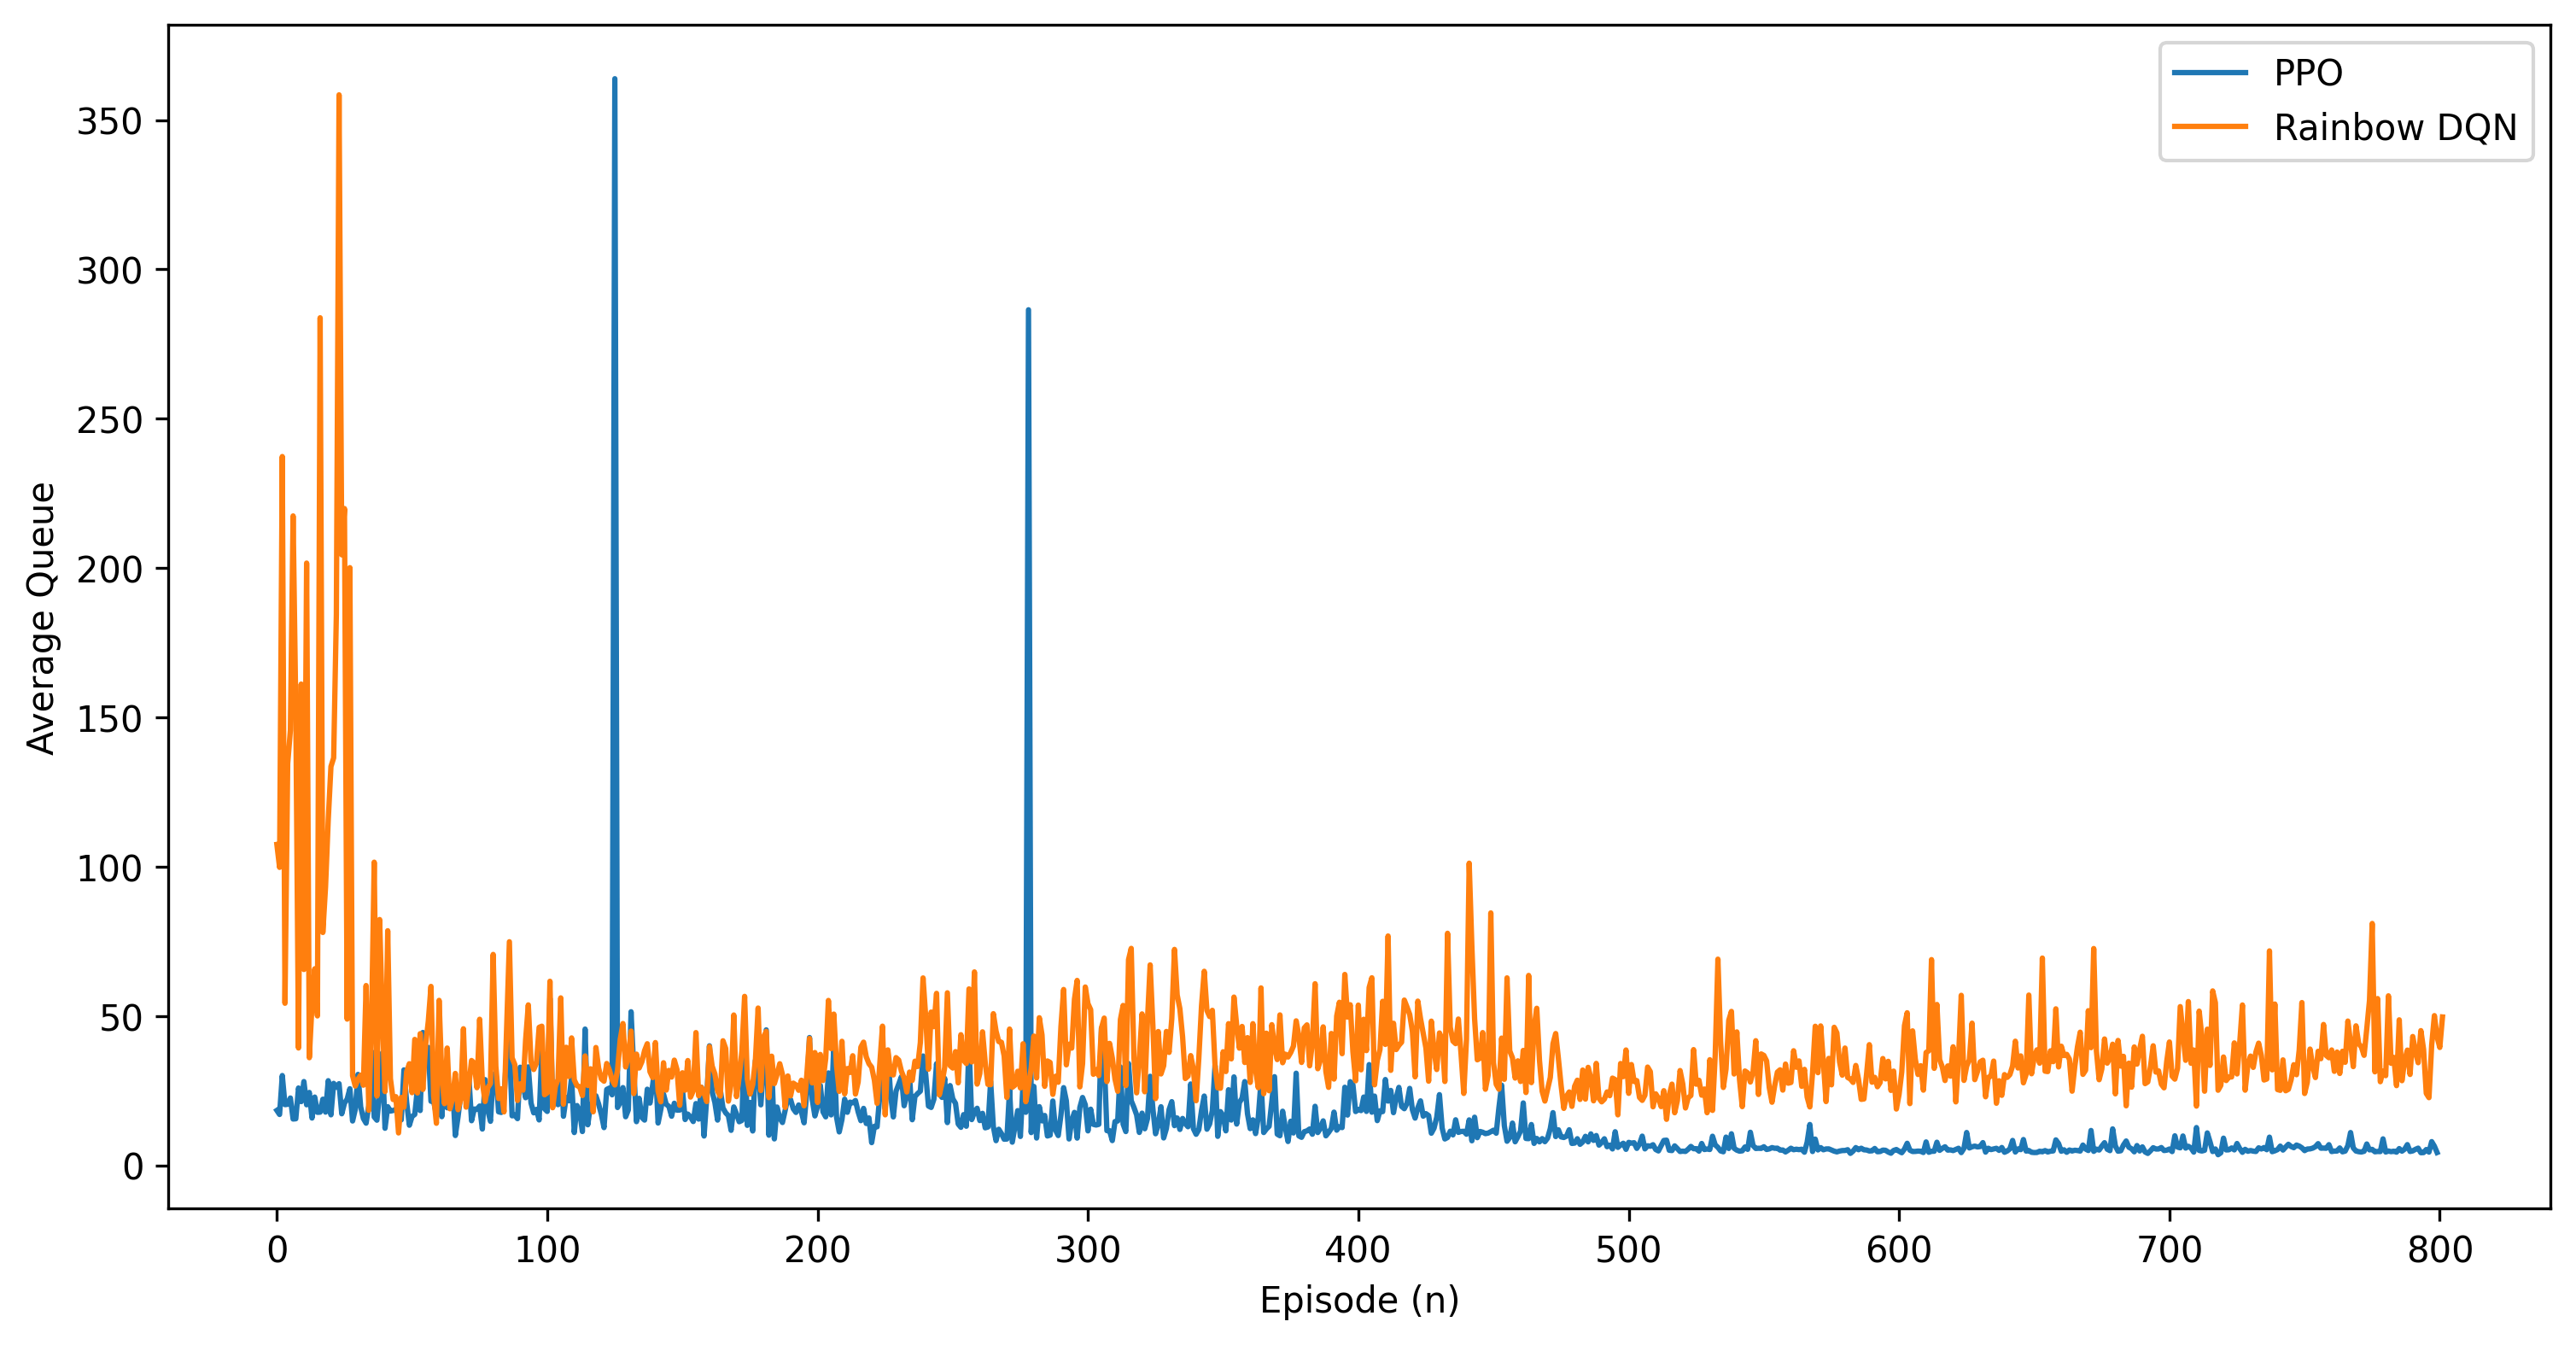

In [10]:
print(ppo_files[4])
delay_ppo = np.loadtxt(ppo_files[4])

print(dqn_files[1])
delay_dqn = np.loadtxt(dqn_files[1])

plt.figure(figsize=(12,6), dpi = 300)
plt.plot(delay_ppo, label='PPO')
plt.plot(delay_dqn, label='Rainbow DQN')
plt.ylabel('Average Queue')
plt.xlabel('Episode (n)')
plt.legend()
plt.savefig('./comparison_queues.png')
plt.show()

.\comparison\PPO_reward_data.txt
.\comparison\RDQN_reward_data.txt


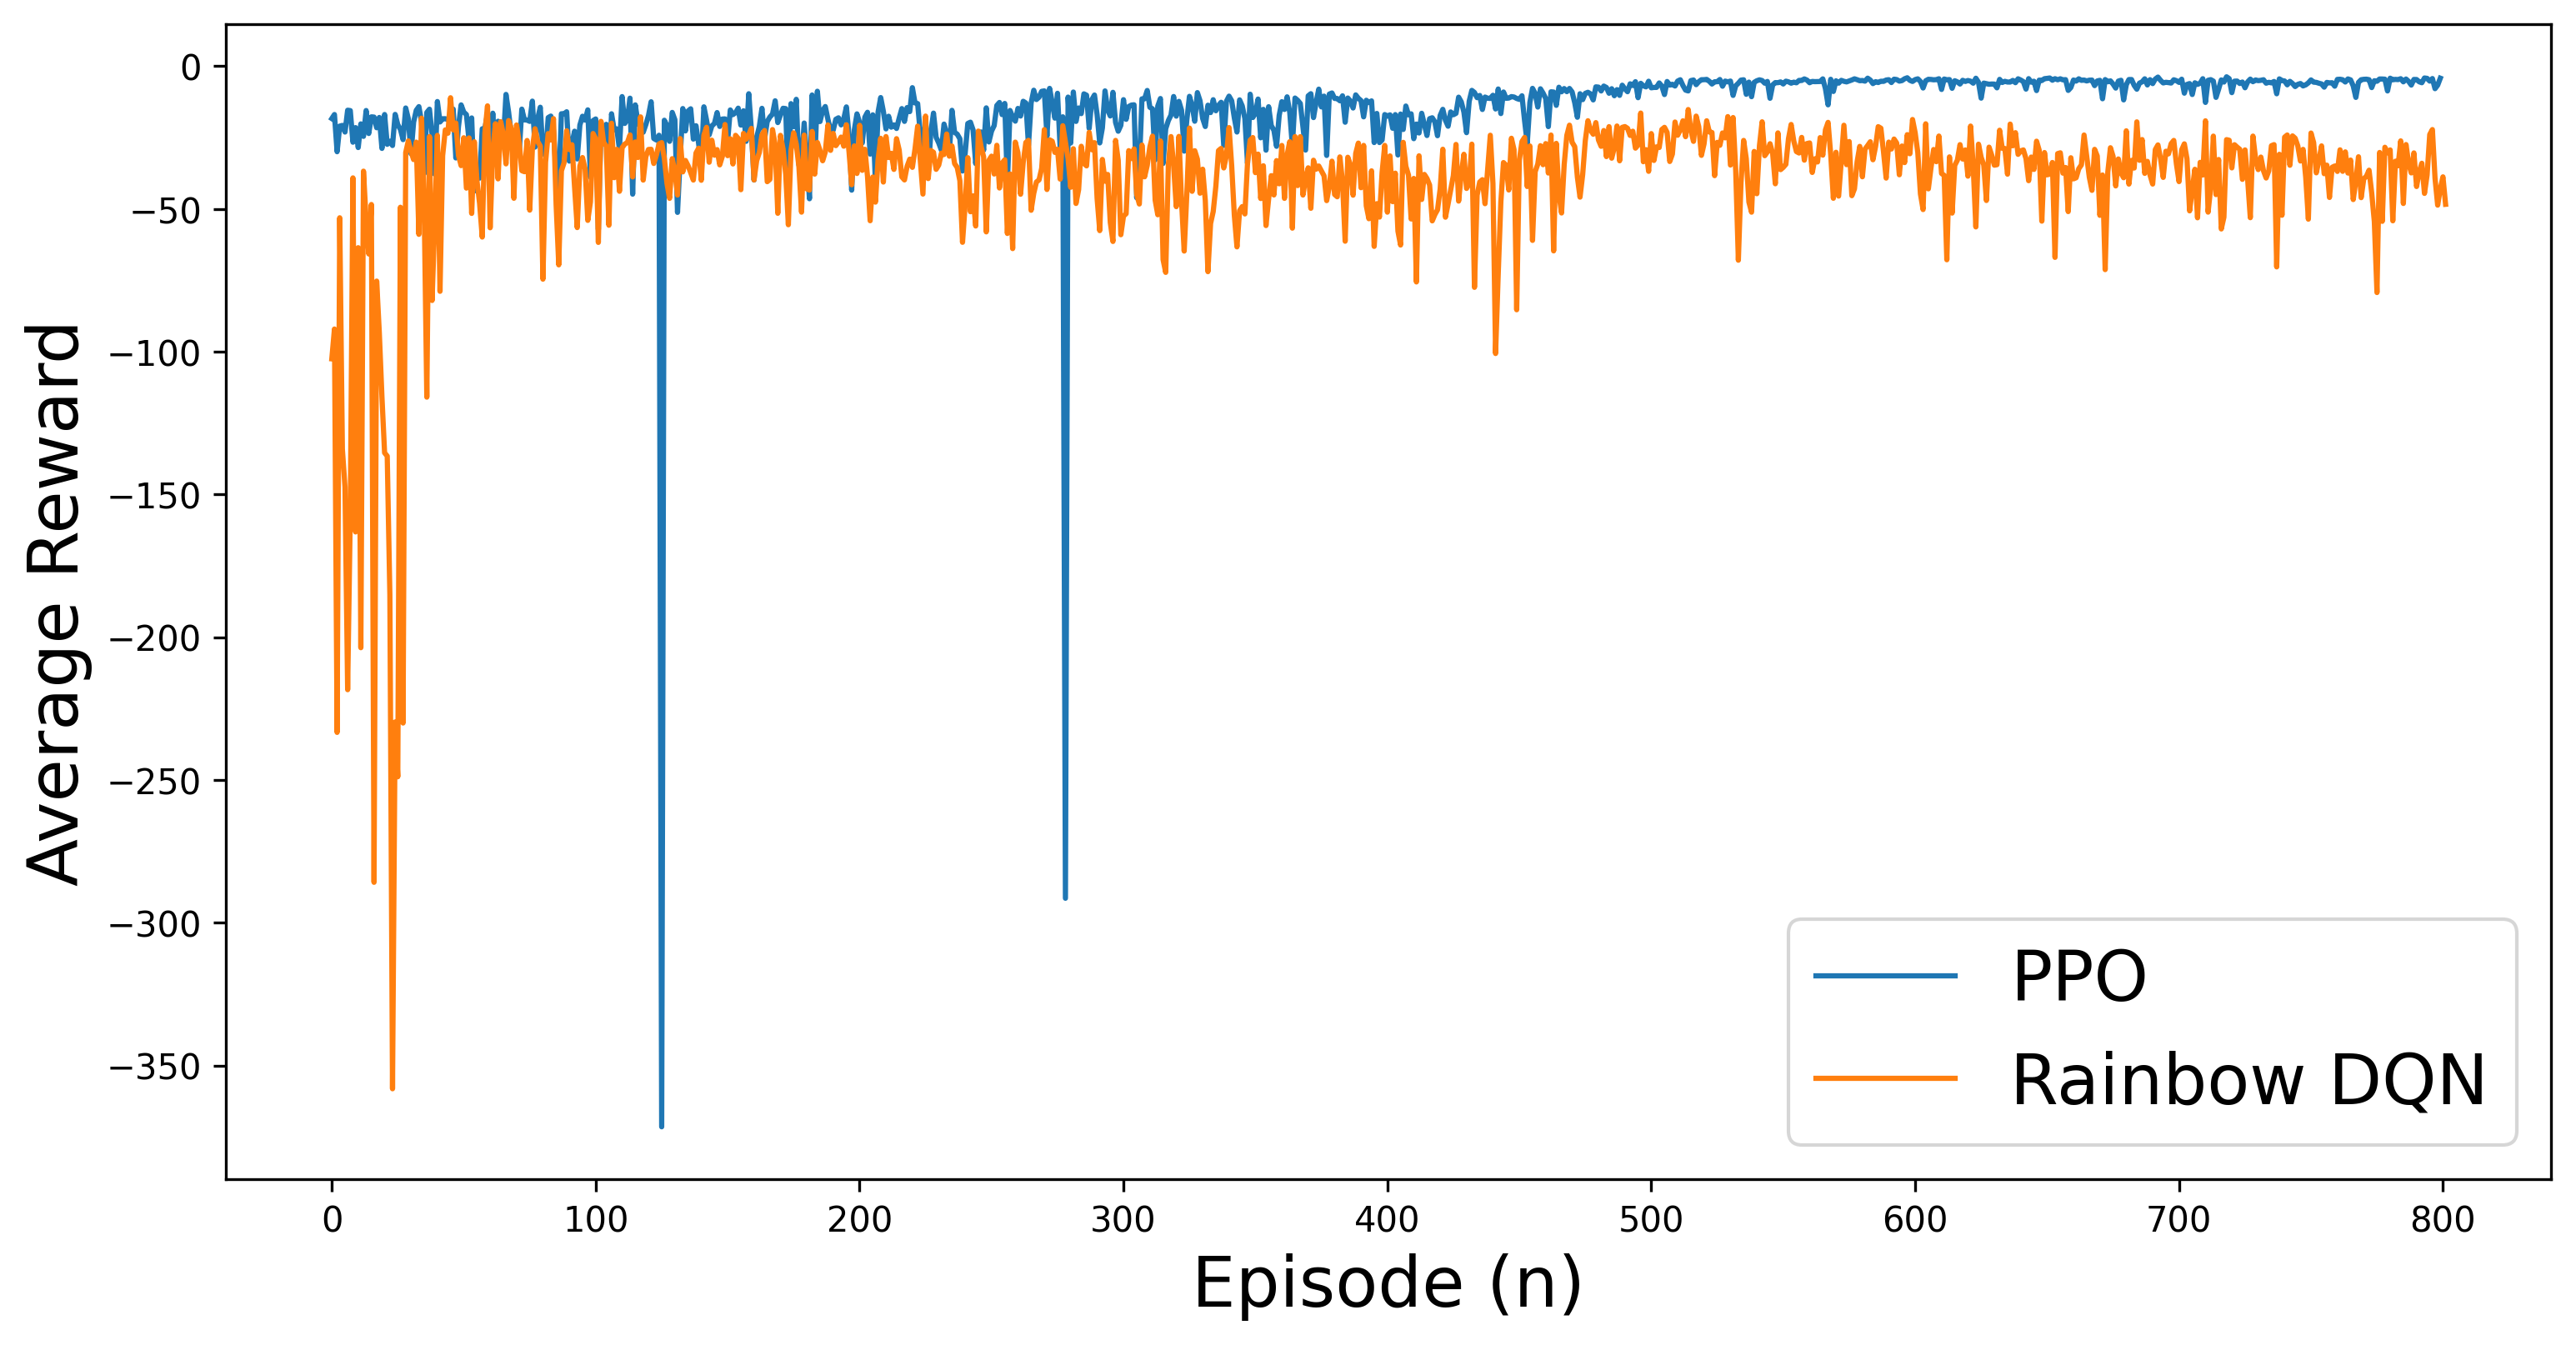

In [8]:
print(ppo_files[5])
delay_ppo = np.loadtxt(ppo_files[5])

print(dqn_files[2])
delay_dqn = np.loadtxt(dqn_files[2])

plt.figure(figsize=(12,6), dpi = 300)
plt.plot(delay_ppo, label='PPO')
plt.plot(delay_dqn, label='Rainbow DQN')
plt.ylabel('Average Reward', fontsize=20)
plt.xlabel('Episode (n)', fontsize=20)
plt.legend(fontsize=20)
plt.savefig('./comparison_rewards.png', bbox_inches='tight', pad_inches=0.25)
plt.show()

.\comparison\PPO_Speed_data.txt
.\comparison\RDQN_Speed_data.txt


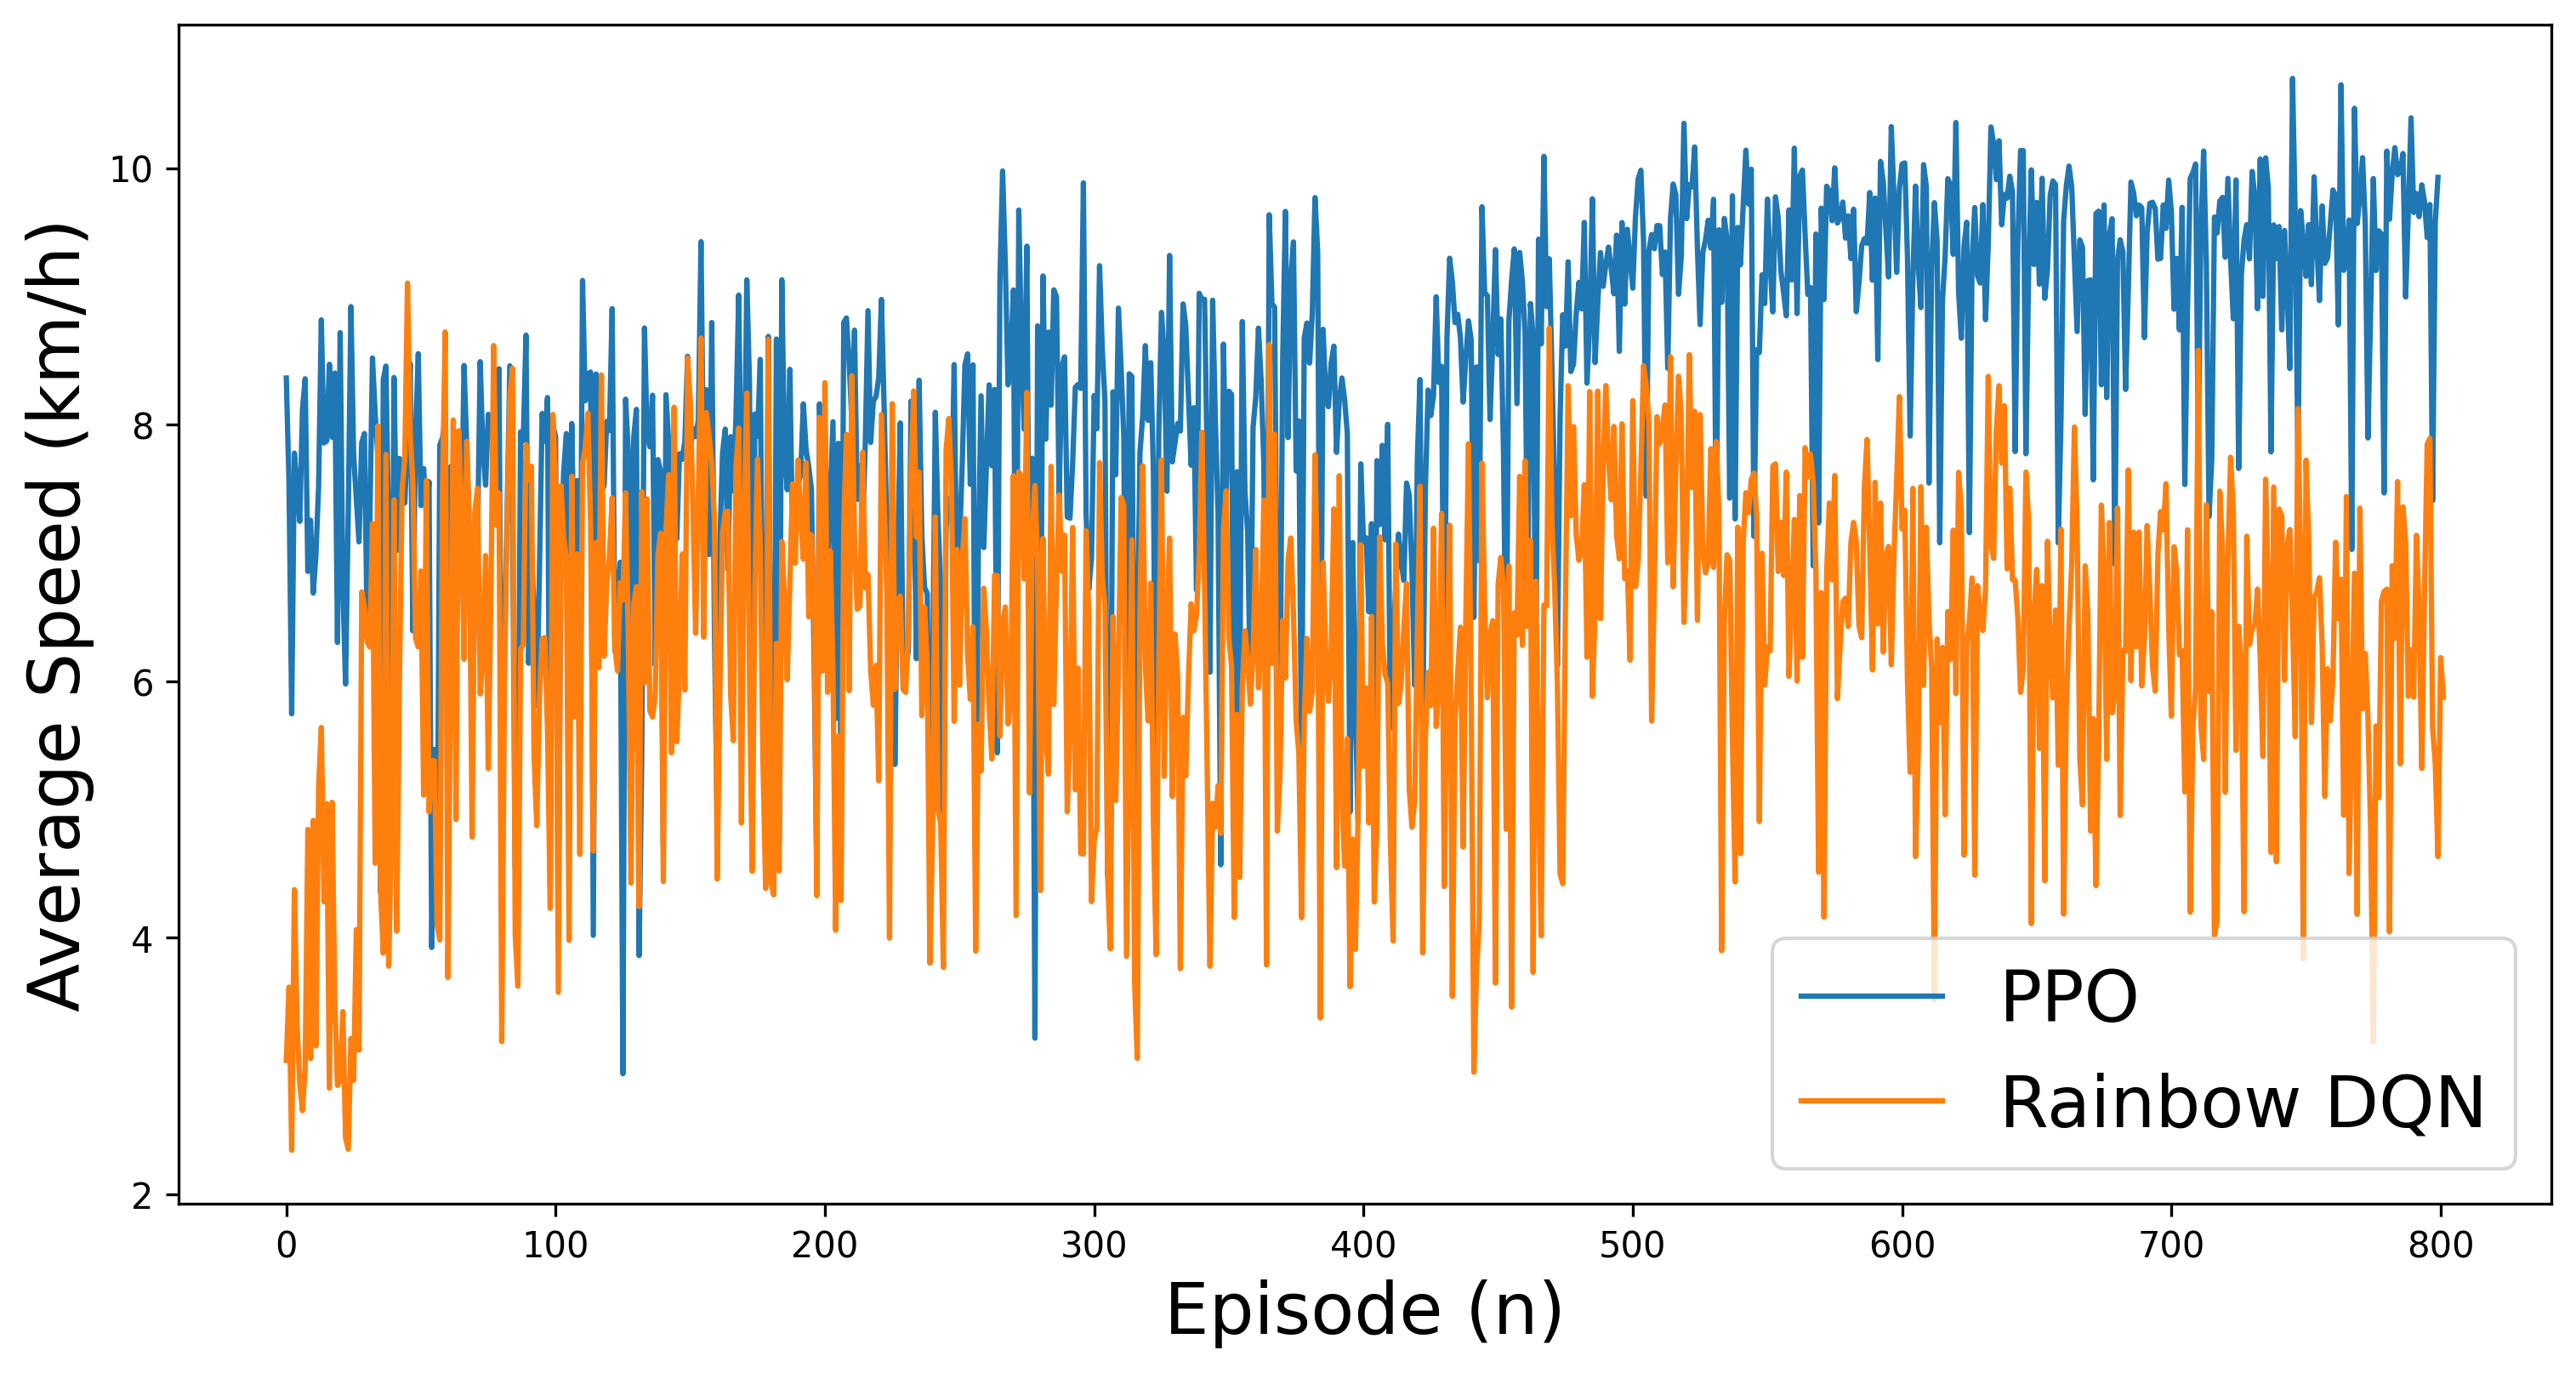

In [10]:
print(ppo_files[6])
delay_ppo = np.loadtxt(ppo_files[6])

print(dqn_files[3])
delay_dqn = np.loadtxt(dqn_files[3])

plt.figure(figsize=(12,6), dpi = 300)
plt.plot(delay_ppo, label='PPO')
plt.plot(delay_dqn, label='Rainbow DQN')
plt.ylabel('Average Speed (km/h)', fontsize=20)
plt.xlabel('Episode (n)', fontsize=20)
plt.legend(fontsize=20)
plt.savefig('./comparison_speeds.png', bbox_inches='tight', pad_inches=0.25)
plt.show()

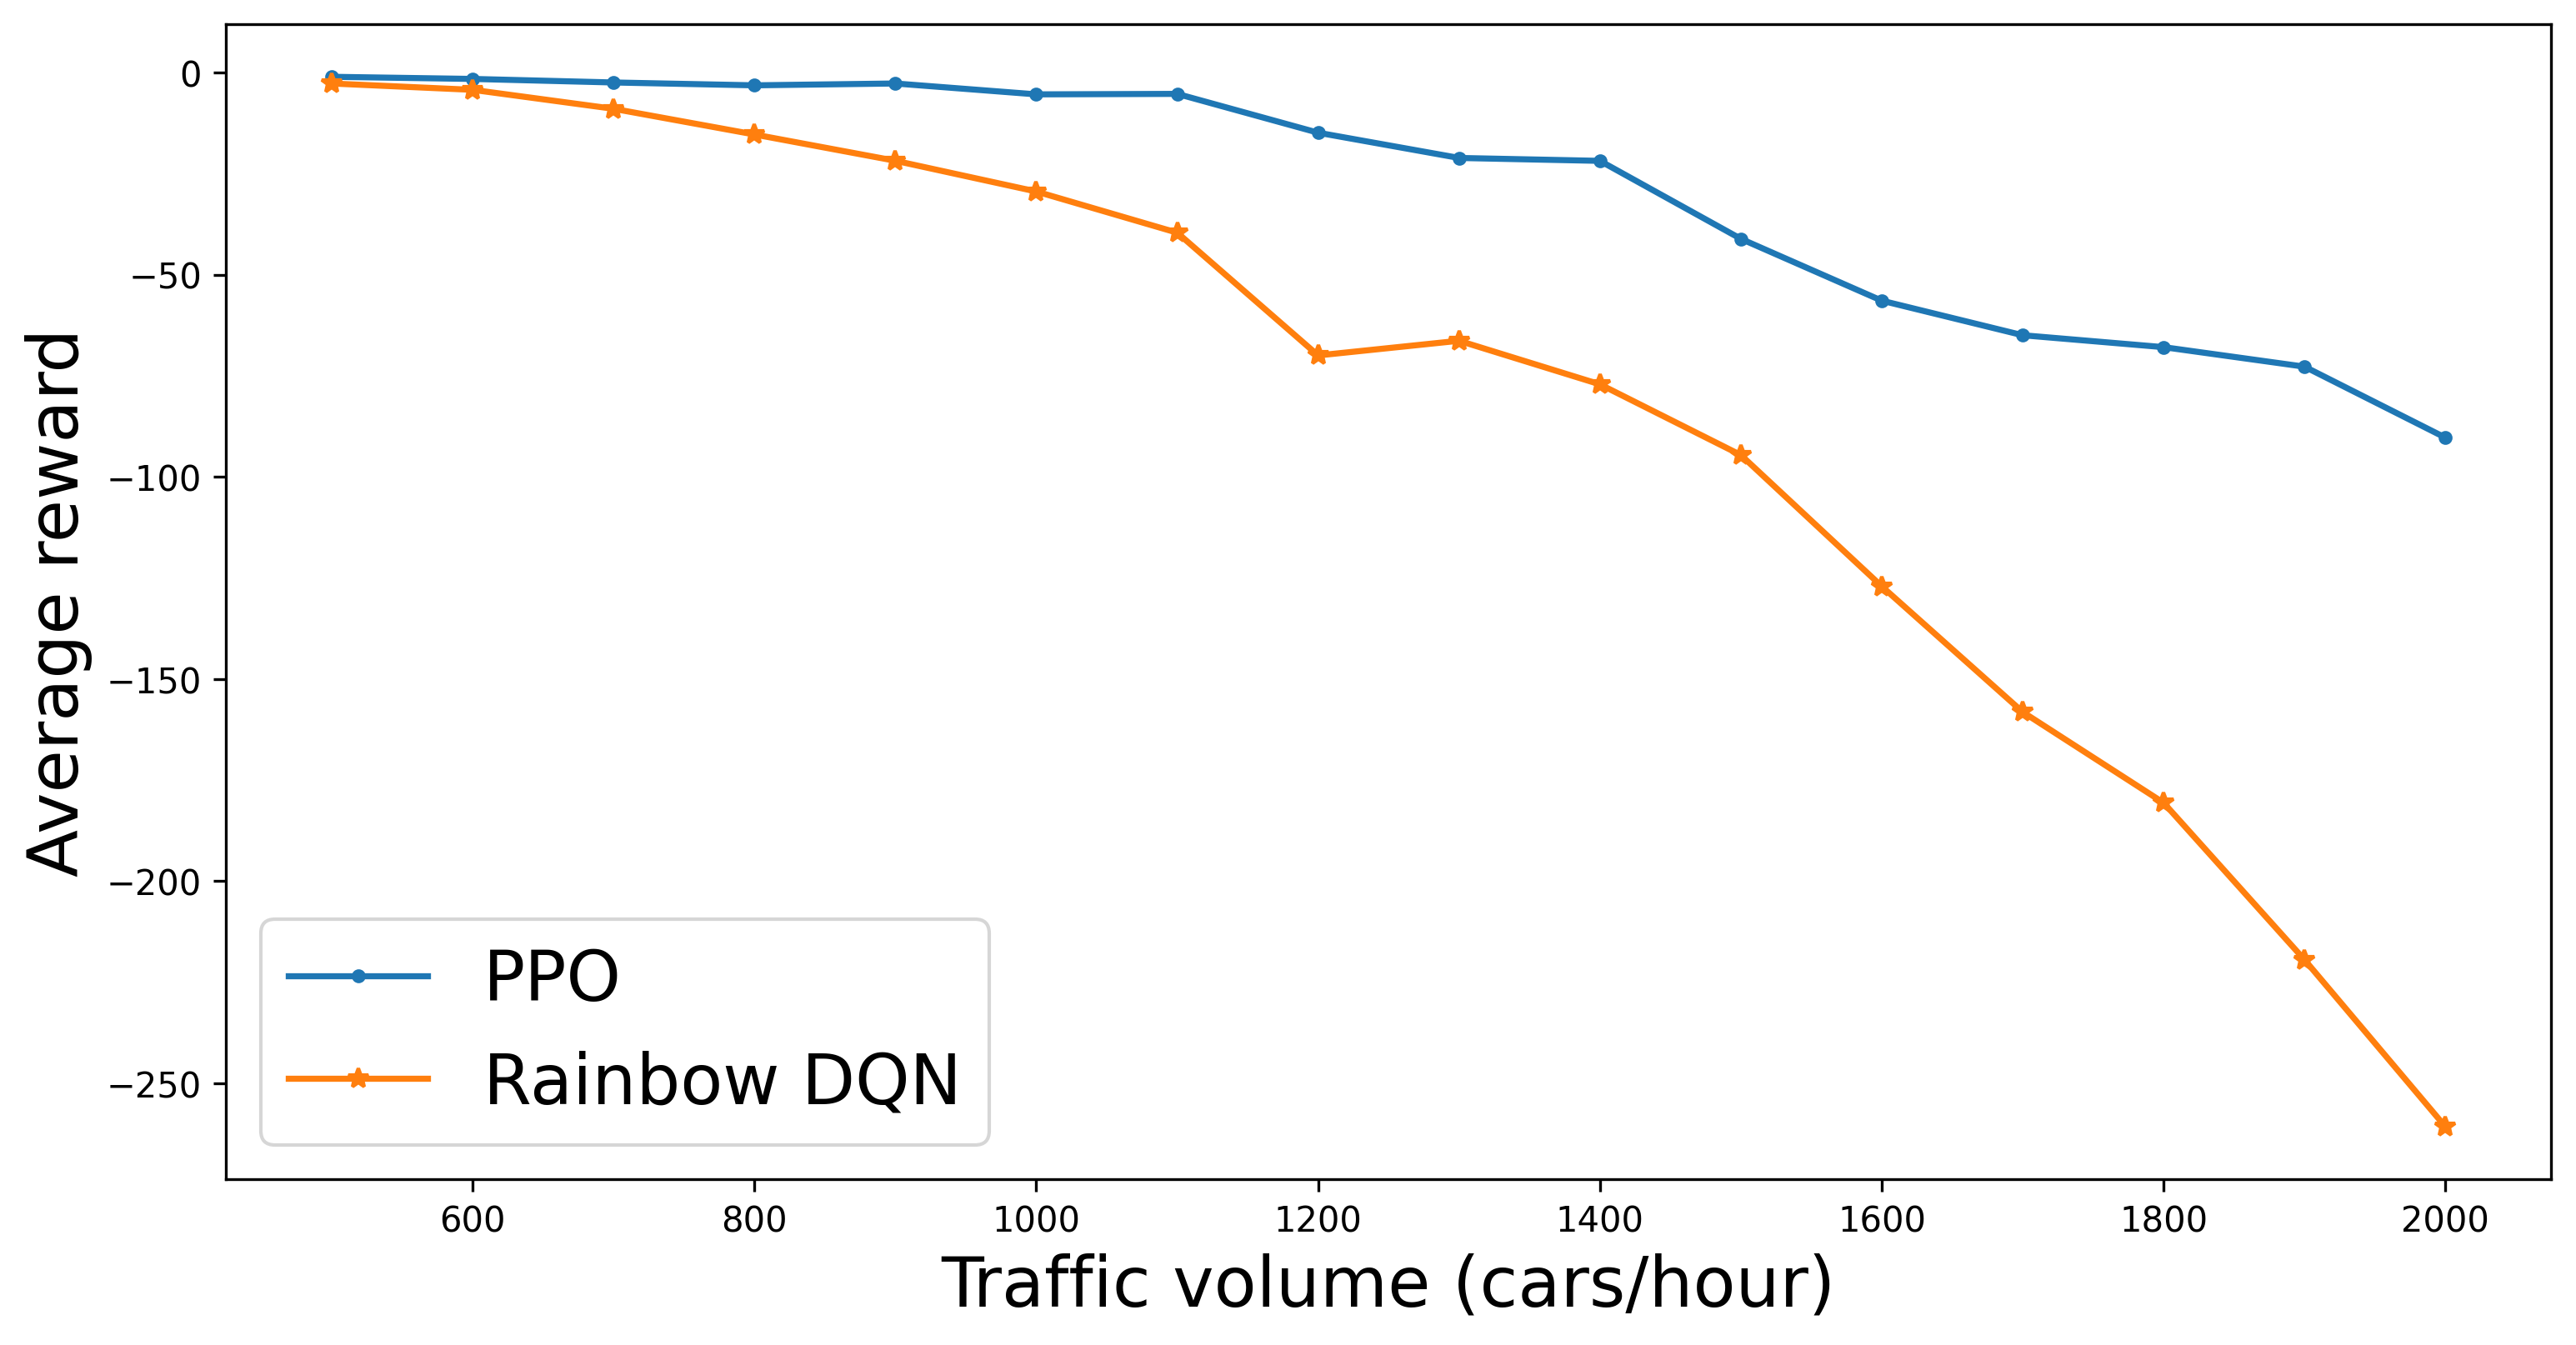

In [12]:
eval_ppo = np.loadtxt(ppo_files[0])
eval_rdqn= np.loadtxt(dqn_files[0])

demand = [i for i in range(500,2100,100)]

plt.figure(figsize= (12,6), dpi = 300)
plt.plot(demand, eval_ppo, label='PPO', marker='.', linewidth=1.75)
plt.plot(demand, eval_rdqn, label='Rainbow DQN', marker='*', linewidth=1.75)
plt.xlabel('Traffic volume (cars/hour)', fontsize=20)
plt.ylabel('Average reward', fontsize=20)
plt.legend(fontsize=20)
plt.savefig('./comparison_eval.png', bbox_inches='tight', pad_inches=0.25)
plt.show()